# UltraMedical-Preference — Analyse Exploratoire (EDA)

## Synthèse & Observations

### Structure du dataset
- **Langue :** Anglais | **Source :** Tsinghua (`TsinghuaC3I/UltraMedical-Preference` sur HuggingFace)
- Format **préférentiel** (chosen/rejected) — conversations générées par IA et annotées par préférence
- 1 seul split : `train` (109 353 lignes) — plus grande source du corpus
- Colonnes : `prompt_id`, `label_type`, `prompt`, `chosen` (list[dict]), `rejected` (list[dict]), `metadata`, `feedback`
- `chosen` et `rejected` = listes de messages `{role: user|assistant, content: ...}`
- **Toujours exactement 2 messages** par conversation (1 user + 1 assistant) — vérifié

### Points d'attention
- Format conversationnel → nécessite une extraction avant usage en SFT
- `chosen` = réponse préférée (meilleure qualité) | `rejected` = réponse moins bonne
- `label_type` : critère de sélection des préférences (length, easy, hard...)
- `prompt_id` encode la source d'origine (ex: `MedMCQA,11404`, `ChatDoctor,33567`, `WikiInstruct,8304`)
- `metadata` et `feedback` : évaluations qualitatives narratives → non pertinentes pour le SFT
- **Double usage possible** : `chosen` → SFT | paires `chosen/rejected` → DPO (alignement par préférences)

### Décisions de nettoyage → `src/processing/ultramed_cleaning.py`
- Extraire le 1er message `user` de `chosen` → colonne `question`
- Extraire le 1er message `assistant` de `chosen` → colonne `answer`
- Supprimer les doublons
- Normaliser en minuscules | Ajouter `dataset_name = "ultramed"`
- **Conserver les paires `chosen/rejected` originales** pour l'entraînement DPO ultérieur

---
## 1. Chargement des données

In [1]:
from datasets import load_from_disk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Fabien\Desktop\OC\P14\FINE-TUNING_MEDICAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ultraMed_Dataset = load_from_disk("gs://p14-medical-data/raw_data/UltraMedical_dataset")
print(ultraMed_Dataset)

DatasetDict({
    train: Dataset({
        features: ['prompt_id', 'label_type', 'prompt', 'chosen', 'rejected', 'metadata', 'feedback'],
        num_rows: 109353
    })
    validation: Dataset({
        features: ['prompt_id', 'label_type', 'prompt', 'chosen', 'rejected', 'metadata', 'feedback'],
        num_rows: 2232
    })
    test: Dataset({
        features: ['prompt_id', 'label_type', 'prompt', 'chosen', 'rejected', 'metadata', 'feedback'],
        num_rows: 777
    })
})


---
## 2. Exploration de la structure

In [3]:
df = pd.DataFrame(ultraMed_Dataset["train"])
print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
df.head(3)

Shape : (109353, 7)
Colonnes : ['prompt_id', 'label_type', 'prompt', 'chosen', 'rejected', 'metadata', 'feedback']


,prompt_id,label_type,prompt,chosen,rejected,metadata,feedback
0,"WikiInstruct,8304",length,Investigate the intricacies of immunometabolis...,[{'content': 'Investigate the intricacies of i...,[{'content': 'Investigate the intricacies of i...,{'chosen': {'evaluation': 'This response is ex...,Assistant A provides a detailed and comprehens...
1,"WikiInstruct,8846",length,Examine the differential immunotoxic effects e...,[{'content': 'Examine the differential immunot...,[{'content': 'Examine the differential immunot...,{'chosen': {'evaluation': 'This response effec...,"Assistant A's response is well-structured, pro..."
2,"MedMCQA,11404",length,A lady comes with melanotic pigmentation of li...,[{'content': 'A lady comes with melanotic pigm...,[{'content': 'A lady comes with melanotic pigm...,{'chosen': {'evaluation': 'The response is det...,Both Assistant A and Assistant B provided answ...


In [4]:
df.isna().sum()

prompt_id     0
label_type    0
prompt        0
chosen        0
rejected      0
metadata      0
feedback      0
dtype: int64

---
## 3. Analyse du format conversationnel

In [5]:
# Nombre de messages par conversation (chosen)
df["nb_messages_chosen"] = df["chosen"].apply(len)
print("Distribution du nombre de messages dans 'chosen' :")
print(df["nb_messages_chosen"].value_counts())

Distribution du nombre de messages dans 'chosen' :
nb_messages_chosen
2    109353
Name: count, dtype: int64


In [6]:
# Structure d'un message chosen : liste de dicts {role, content}
example = df["chosen"].iloc[0]
print(f"Nombre de messages : {len(example)}")
for msg in example:
    print(f"  role  : {msg['role']}")
    print(f"  content (extrait) : {msg['content'][:200]}")
    print()

Nombre de messages : 2
  role  : user
  content (extrait) : Investigate the intricacies of immunometabolism, a distinct subfield of immunology that examines the interconnection between cellular metabolic processes and the functional attributes of immune cells.

  role  : assistant
  content (extrait) :  Immunometabolism is an emerging field of study that explores the intersection between cellular metabolic processes and the functional attributes of immune cells. This subfield has gained significant 



In [7]:
# Vérification que le pattern user/assistant est systématique
roles_chosen = df["chosen"].apply(lambda msgs: tuple(m["role"] for m in msgs))
print("Patterns de rôles dans 'chosen' :")
print(roles_chosen.value_counts())

Patterns de rôles dans 'chosen' :
chosen
(user, assistant)    109353
Name: count, dtype: int64


---
## 4. Distribution des variables clés

In [8]:
# Distribution du label_type (critère de sélection de la préférence)
df["label_type"].value_counts()

label_type
hard      45765
length    41130
easy      22458
Name: count, dtype: int64

In [9]:
# Sources d'origine des conversations (encodées dans prompt_id)
df["source"] = df["prompt_id"].str.split(",").str[0]
print("Top 15 sources d'origine :")
print(df["source"].value_counts().head(15))

Top 15 sources d'origine :
source
WikiInstruct             27493
MedMCQA                  17554
TextBookQA               16014
ChatDoctor               11309
MedQA                    10803
MedQA-Evol                9239
MedQuad                   5855
Medical-Instruct-120k     4952
PubMedQA                  3293
MedInstruct-52k           2841
Name: count, dtype: int64


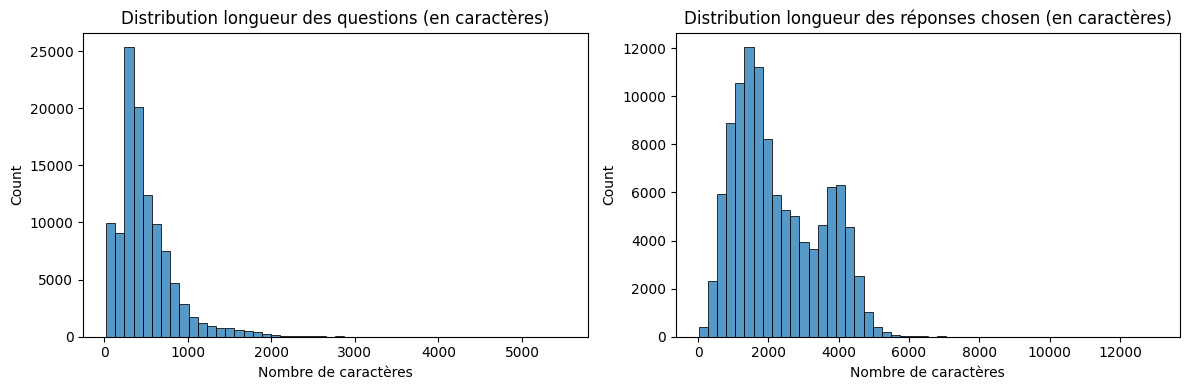

In [10]:
# Extraction des questions et réponses pour analyse des longueurs
df["question_text"] = df["chosen"].apply(
    lambda msgs: next((m["content"] for m in msgs if m["role"] == "user"), None)
)
df["answer_text"] = df["chosen"].apply(
    lambda msgs: next((m["content"] for m in msgs if m["role"] == "assistant"), None)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["question_text"].str.len(), bins=50, ax=axes[0])
axes[0].set_title("Distribution longueur des questions (en caractères)")
axes[0].set_xlabel("Nombre de caractères")

sns.histplot(df["answer_text"].str.len(), bins=50, ax=axes[1])
axes[1].set_title("Distribution longueur des réponses chosen (en caractères)")
axes[1].set_xlabel("Nombre de caractères")

plt.tight_layout()
plt.show()

---
## 5. Analyse des doublons

In [11]:
# Doublons sur le prompt
print(f"Doublons sur 'prompt' : {df.duplicated(subset=['prompt']).sum()}")
print(f"Doublons sur 'prompt_id' : {df.duplicated(subset=['prompt_id']).sum()}")

Doublons sur 'prompt' : 32829
Doublons sur 'prompt_id' : 32307


---
## 6. Aperçu des paires chosen/rejected (usage DPO)

In [12]:
# Exemple d'une paire chosen/rejected pour l'entraînement DPO
sample = df.iloc[2]
print("=== PROMPT ===")
print(sample["prompt"][:300])
print()
print("=== CHOSEN (réponse préférée) ===")
chosen_answer = next(m["content"] for m in sample["chosen"] if m["role"] == "assistant")
print(chosen_answer[:400])
print()
print("=== REJECTED (réponse moins bonne) ===")
rejected_answer = next(m["content"] for m in sample["rejected"] if m["role"] == "assistant")
print(rejected_answer[:400])

=== PROMPT ===
A lady comes with melanotic pigmentation of lip, presence of multiple polyps in the intestine, and a positive family history. What is the most probable diagnosis?

A. Peutz-Jegher's Syndrome
B. Gardner's syndrome
C. Turcot's syndrome
D. Lynch syndrome

=== CHOSEN (réponse préférée) ===


Let's think step by step.

The patient has melanotic pigmentation of the lip, which is a characteristic feature of Peutz-Jeghers syndrome. Additionally, the presence of multiple polyps in the intestine also points towards Peutz-Jeghers syndrome, as it is a rare autosomal dominant disorder characterized by hamartomatous polyps in the gastrointestinal tract.

The positive family history further su

=== REJECTED (réponse moins bonne) ===
Let's break down the symptoms:

* Melanotic pigmentation of the lip: This is a common feature of several genetic syndromes.
* Presence of multiple polyps in the intestine: This suggests a genetic disorder affecting the gastrointestinal tract.
* Positive fam